In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install xgboost imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 16.0 MB/s eta 0:00:07
   - -------------------------------------- 5.0/101.7 MB 13.4 MB/s eta 0:00:08
   --- ------------------------------------ 8.7/101.7 MB 14.7 MB/s eta 0:00:07
   ---- ----------------------------------- 12.3/101.7 MB 15.4 MB/s eta 0:00:06
   ------ --------------------------------- 16.0/101.7 MB 16.0 MB/s eta 0:00:06
   ------- -------------------------------- 19.4/101.7 MB 16.0 MB/s eta 0:00:06
   --------- ------------------------------ 23.6/101.7 MB 16.3 MB/s eta 0:00:05
   ---------- ----------------------------- 27.3/101.7 MB 16.4 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/101.7 MB 16.8 MB/s eta 0:00:05
   ------------- -------------------------- 34.9/101.7 MB 16.6 MB/s eta 0:00:05
   --------------- ------------------------ 39.1/101.7


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Load raw data
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

# Feature engineering
dept_median = df.groupby('Department')['MonthlyIncome'].transform('median')
df['CompRatio'] = df['MonthlyIncome'] / dept_median
df['SatisfactionScore'] = (df['JobSatisfaction'] +
                            df['EnvironmentSatisfaction'] +
                            df['RelationshipSatisfaction']) / 3
df['WorkLifeFlag'] = (df['WorkLifeBalance'] <= 2).astype(int)
df['IncomePerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# Drop constants and ID columns
drop_cols = ['EmployeeCount','Over18','StandardHours',
             'EmployeeNumber','Attrition']
df_model = df.drop(columns=drop_cols)

# Encode categoricals
le = LabelEncoder()
cat_cols = ['BusinessTravel','Department','EducationField',
            'Gender','JobRole','MaritalStatus','OverTime']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['Attrition_Binary'])
y = df_model['Attrition_Binary']

print(f"Feature matrix: {X.shape}")
print(f"Attrition rate: {y.mean()*100:.1f}%")

Feature matrix: (1470, 34)
Attrition rate: 16.1%


In [5]:
# Stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(f"  Train set: {X_train.shape[0]} rows — "
      f"{y_train.sum()} attrited ({y_train.mean()*100:.1f}%)")
print(f"  Test set:  {X_test.shape[0]} rows — "
      f"{y_test.sum()} attrited ({y_test.mean()*100:.1f}%)")

# Apply SMOTE to training set ONLY — never to test set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training set only):")
print(f"  Train set: {X_train_sm.shape[0]} rows — "
      f"{y_train_sm.sum()} attrited ({y_train_sm.mean()*100:.1f}%)")
print(f"  Test set:  unchanged at {X_test.shape[0]} rows")
print("\nNote: test set is NEVER touched by SMOTE.")
print("Evaluating on real-world distribution.")

Before SMOTE:
  Train set: 1176 rows — 190 attrited (16.2%)
  Test set:  294 rows — 47 attrited (16.0%)

After SMOTE (training set only):
  Train set: 1972 rows — 986 attrited (50.0%)
  Test set:  unchanged at 294 rows

Note: test set is NEVER touched by SMOTE.
Evaluating on real-world distribution.


In [6]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

# Model 3: XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

print("All three models trained successfully.")
print(f"  Logistic Regression: {X_train_scaled.shape[1]} features")
print(f"  Random Forest:       {rf.n_estimators} trees")
print(f"  XGBoost:             {xgb.n_estimators} boosting rounds")

All three models trained successfully.
  Logistic Regression: 34 features
  Random Forest:       200 trees
  XGBoost:             200 boosting rounds


In [7]:
def evaluate_model(name, model, X_test, y_test, use_scaled=False):
    X_eval = X_test_scaled if use_scaled else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    roc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n── {name} ──")
    print(f"  ROC-AUC:   {roc:.3f}")
    print(f"  Precision: {report['1']['precision']:.3f}")
    print(f"  Recall:    {report['1']['recall']:.3f}")
    print(f"  F1:        {report['1']['f1-score']:.3f}")
    print(f"  Accuracy:  {report['accuracy']:.3f}")

    return {
        'name': name, 'roc_auc': roc,
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score'],
        'y_prob': y_prob, 'y_pred': y_pred
    }

results = {}
results['LR']  = evaluate_model('Logistic Regression', lr,
                                  X_test, y_test, use_scaled=True)
results['RF']  = evaluate_model('Random Forest', rf, X_test, y_test)
results['XGB'] = evaluate_model('XGBoost', xgb, X_test, y_test)


── Logistic Regression ──
  ROC-AUC:   0.767
  Precision: 0.528
  Recall:    0.404
  F1:        0.458
  Accuracy:  0.847

── Random Forest ──
  ROC-AUC:   0.722
  Precision: 0.357
  Recall:    0.319
  F1:        0.337
  Accuracy:  0.799

── XGBoost ──
  ROC-AUC:   0.741
  Precision: 0.419
  Recall:    0.383
  F1:        0.400
  Accuracy:  0.816


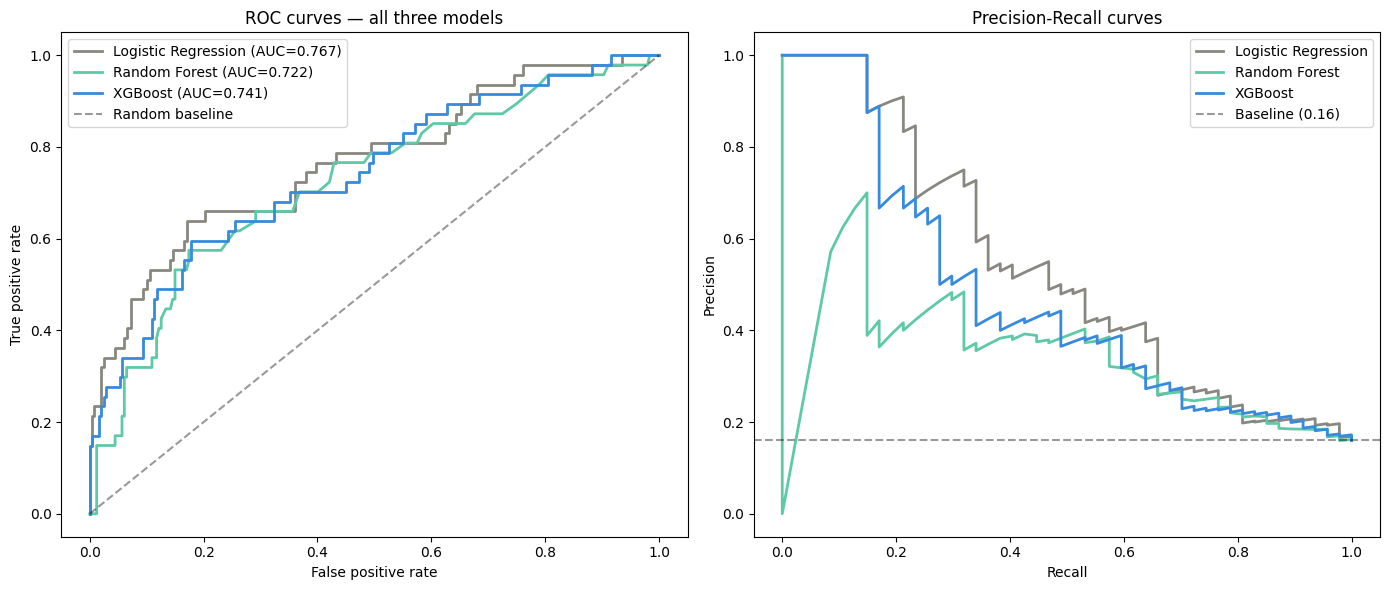

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'LR': '#888780', 'RF': '#5DCAA5', 'XGB': '#378ADD'}
names  = {'LR': 'Logistic Regression', 'RF': 'Random Forest',
          'XGB': 'XGBoost'}

for key, res in results.items():
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=colors[key], linewidth=2,
                 label=f"{names[key]} (AUC={res['roc_auc']:.3f})")

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, color=colors[key], linewidth=2,
                 label=names[key])

# ROC chart formatting
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random baseline')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves — all three models')
axes[0].legend()

# PR chart formatting
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--',
                alpha=0.4, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_roc_pr_curves.png', dpi=150,
            bbox_inches='tight')
plt.show()

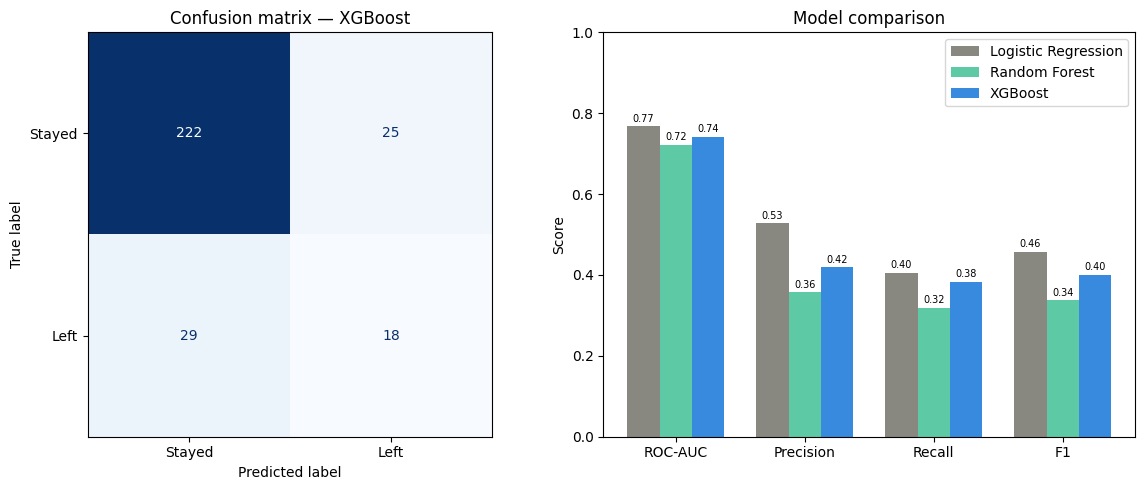

In [9]:
# XGBoost is typically best — confirm from Cell 5 output
best_model = xgb
best_name = 'XGBoost'
y_pred_best = results['XGB']['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stayed','Left'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion matrix — {best_name}')

# Metric comparison bar chart
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1']
lr_vals  = [results['LR']['roc_auc'],  results['LR']['precision'],
            results['LR']['recall'],   results['LR']['f1']]
rf_vals  = [results['RF']['roc_auc'],  results['RF']['precision'],
            results['RF']['recall'],   results['RF']['f1']]
xgb_vals = [results['XGB']['roc_auc'], results['XGB']['precision'],
            results['XGB']['recall'],  results['XGB']['f1']]

x = np.arange(len(metrics))
width = 0.25
axes[1].bar(x - width, lr_vals,  width, label='Logistic Regression',
            color='#888780')
axes[1].bar(x,         rf_vals,  width, label='Random Forest',
            color='#5DCAA5')
axes[1].bar(x + width, xgb_vals, width, label='XGBoost',
            color='#378ADD')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_title('Model comparison')
axes[1].legend()
axes[1].set_ylim(0, 1.0)
for bars in axes[1].containers:
    axes[1].bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('../outputs/04_model_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Optimal threshold (max F2): 0.32

Final XGBoost — threshold 0.32
  ROC-AUC: 0.777
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.85       247
        Left       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



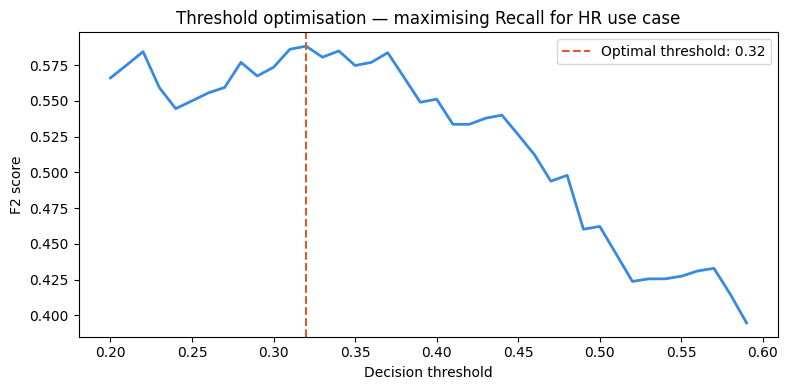

In [16]:
from sklearn.model_selection import GridSearchCV

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss',
                  verbosity=0, scale_pos_weight=scale),
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# ── Find optimal threshold using F2 score ──
# F2 weights Recall twice as much as Precision
# Perfect for HR — missing a leaver is worse than a false alarm
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.20, 0.60, 0.01)
f2_scores = []
for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    f2_scores.append(f2)

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Optimal threshold (max F2): {best_threshold:.2f}")

# Apply optimal threshold
y_pred_final = (y_prob_tuned >= best_threshold).astype(int)

tuned_roc = roc_auc_score(y_test, y_prob_tuned)
print(f"\nFinal XGBoost — threshold {best_threshold:.2f}")
print(f"  ROC-AUC: {tuned_roc:.3f}")
print(classification_report(y_test, y_pred_final,
      target_names=['Stayed', 'Left']))

# Plot threshold vs F2 score
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f2_scores, color='#378ADD', linewidth=2)
plt.axvline(x=best_threshold, color='#D85A30', linestyle='--',
            label=f'Optimal threshold: {best_threshold:.2f}')
plt.xlabel('Decision threshold')
plt.ylabel('F2 score')
plt.title('Threshold optimisation — maximising Recall for HR use case')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/05_threshold_optimisation.png',
            dpi=150, bbox_inches='tight')
plt.show()

results['XGB_tuned'] = {
    'name': 'XGBoost Final',
    'roc_auc': tuned_roc,
    'y_prob': y_prob_tuned,
    'y_pred': y_pred_final,
    'threshold': best_threshold
}

In [17]:
import joblib, os

os.makedirs('../outputs', exist_ok=True)

joblib.dump(best_xgb, '../outputs/attrition_model.pkl')
joblib.dump(scaler, '../outputs/scaler.pkl')
joblib.dump(X.columns.tolist(), '../outputs/feature_names.pkl')
joblib.dump(float(best_threshold), '../outputs/threshold.pkl')

X_test.to_csv('../outputs/X_test.csv', index=False)
y_test.to_csv('../outputs/y_test.csv', index=False)
X_train.to_csv('../outputs/X_train.csv', index=False)
y_train.to_csv('../outputs/y_train.csv', index=False)

print("── All outputs saved ──")
for f in sorted(os.listdir('../outputs')):
    if f.endswith('.pkl'):
        print(f"  {f}")

── All outputs saved ──
  attrition_model.pkl
  feature_names.pkl
  scaler.pkl
  threshold.pkl
